This notebook compute the symbolic distributions of $Y_n$. The recurrence is defined as

$$Y_{n+1} = I^{(n)}\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J^{(n)}\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_1=0.$$

Given that the subscripts are for iid copies. The variables $I^{(n)}$ and $J^{(n)}$ are Bernoulli with expectation $u$ and $v$ respectively such that $I^{(n)}+J^{(n)}\le 1$, and they are inpependent of all $Y^{(j)}_i$. The variable $U_n$ is uniform in $\{0,\ldots,n-1\}$. All the collections of iid copies are independent.

In [7]:
# sage -n jupyter --no-browser

import os, sys
from pathlib import Path

print("Working directory:", os.getcwd())
print("Kernel executable:", sys.executable)

if sys.executable.lower().endswith('sage'):
  target = Path("/mnt/d/Projects/m2-bezout/internship/src/notebooks/")
  os.chdir(target)
  print("Changed working directory to:", os.getcwd())


import importlib

from utils import styled_print

import monte_carlo
importlib.reload(monte_carlo)
from monte_carlo import sample_from_empirical, plot_distribution, pmf_to_particles

Working directory: /home/stages/chau/projects/m2-bezout/internship/src/local/notebooks
Kernel executable: /home/stages/chau/miniforge3/envs/sage/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
from sage.all import *

In [16]:
def compute_Yn_symbolic(max_N):
    # Declare u and v as symbolic variables
    u, v = var('u v')
    
    # Initialize matrices with Sage's Symbolic Ring (SR) zeros
    pmfs = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    cdfs = [[SR(0)] * (max_N + 1) for _ in range(max_N + 1)]
    
    # Base cases: Y_0 = 0, Y_1 = 0
    pmfs[0][0] = SR(1)
    pmfs[1][0] = SR(1)
    
    for i in range(2):
        for k in range(max_N + 1):
            cdfs[i][k] = SR(1)

    termination_prob = 1 - u - v

    for n_target in range(2, max_N + 1):
        # n_target is n+1
        n = n_target - 1

        # Y_{n+1} can be at most (n_target+1)//2.
        for k in range((n_target+1)//2+1): 
            prob_k = SR(0)
            
            # U_n is uniformly distributed over {0, ..., n-1}
            for i in range(n):
                idx1 = i
                idx2 = n - 1 - i
                
                # I: sum of independent copies + 1
                c_prob = SR(0)
                if k >= 1:
                    for j in range(k):
                        c_prob += pmfs[idx1][j] * pmfs[idx2][k - 1 - j]
                        
                # J: max of independent copies
                cdfs1_k = cdfs[idx1][k]
                cdfs2_k = cdfs[idx2][k]
                cdfs1_k_minus_1 = cdfs[idx1][k - 1] if k > 0 else SR(0)
                cdfs2_k_minus_1 = cdfs[idx2][k - 1] if k > 0 else SR(0)
                
                m_prob = (cdfs1_k * cdfs2_k) - (cdfs1_k_minus_1 * cdfs2_k_minus_1)
                
                prob_k += u * c_prob + v * m_prob
                
            t_prob = SR(1) if k == 0 else SR(0)
            
            # Divide by n for the uniform distribution expectation
            pmfs[n_target][k] = ((prob_k / n) + (termination_prob * t_prob)).expand()
            
        current_cdf = SR(0)
        for k in range(max_N + 1):
            if k < n_target: 
                current_cdf += pmfs[n_target][k]
            # Store the CDF in n_target, not n
            cdfs[n_target][k] = current_cdf.expand()

    expected_values = []
    for i in range(1, max_N + 1):
        # The expected value calculation correctly ranges up to the max bound
        expected_y = sum(k * pmfs[i][k] for k in range(i))
        expected_values.append(expected_y.expand())

    truncated_pmfs = []
    truncated_cdfs = []
    
    for i in range(max_N + 1):
        
        support_size = i + 1 
        truncated_pmfs.append(pmfs[i][:support_size])
        truncated_cdfs.append(cdfs[i][:support_size])

    return truncated_pmfs, truncated_cdfs, expected_values

In [22]:
pmfs, cdfs, evs = compute_Yn_symbolic(20)

for i in range(10):
    styled_print(pmfs[i])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
def simulate_Yn(max_N, num_particles, u, v, callback=None):

    history = np.zeros((max_N + 1, num_particles), dtype=int)
    
    for n_target in range(3, max_N + 1):
        n = n_target - 2

        # Uniform indices
        Un = np.random.randint(1, n+1, size=num_particles)
        idx1 = Un
        idx2 = n + 1 - Un
        
        # Sample independent copies Y^(1) and Y^(2) 
        p_idx1 = np.random.randint(0, num_particles, size=num_particles)
        p_idx2 = np.random.randint(0, num_particles, size=num_particles)
        
        y1 = history[idx1, p_idx1]
        y2 = history[idx2, p_idx2]
        
        # Determine the Bernoulli events I and J
        rand_vals = np.random.rand(num_particles)
        
        mask_I = rand_vals < u
        mask_J = (rand_vals >= u) & (rand_vals < u + v)
        
        # Apply the recurrence formula conditionally
        y_new = np.zeros(num_particles, dtype=int)
        y_new[mask_I] = y1[mask_I] + y2[mask_I] + 1
        y_new[mask_J] = np.maximum(y1[mask_J], y2[mask_J])
        
        history[n_target] = y_new

        if n_target % 1000 == 0:
            print(f"Interation {n_target}/{max_N} completed.")
    
    return history

In [ ]:
def apply_T(X, u,v, alpha):
    # Sample independent pairs
    X1 = sample_from_empirical(X)
    X2 = sample_from_empirical(X)
    
    # Sample U, I and J
    U = np.random.uniform(0, 1, size=len(X))
    R = np.random.uniform(0, 1, size=len(X))
    
    I = (R < u).astype(np.float64)
    J = ((R >= u) & (R < u + v)).astype(np.float64)
    
    # Apply the operator T_alpha
    term1 = (U**alpha) * X1
    term2 = ((1 - U)**alpha) * X2
    
    T_X = I * (term1 + term2) + J * np.maximum(term1, term2)

    return T_X

def apply_S(X, u, v, alpha):
    Y = apply_T(X, u, v, alpha)
    return Y / np.mean(Y)

In [7]:
def cummulative_mean(alpha, u, v, X, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha(u, v, X_init, lower, upper, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<15} | {'Cumulative Mean':<15}")
    print("-" * 40)
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<15.5f} | {current_mean:<15.5f}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha:.5f}")
    return mid_alpha, X


#### Full experiment

u=0.5, v=0.3
Interation 1000/50000 completed.
Interation 2000/50000 completed.
Interation 3000/50000 completed.
Interation 4000/50000 completed.
Interation 5000/50000 completed.
Interation 6000/50000 completed.
Interation 7000/50000 completed.
Interation 8000/50000 completed.
Interation 9000/50000 completed.
Interation 10000/50000 completed.
Interation 11000/50000 completed.
Interation 12000/50000 completed.
Interation 13000/50000 completed.
Interation 14000/50000 completed.
Interation 15000/50000 completed.
Interation 16000/50000 completed.
Interation 17000/50000 completed.
Interation 18000/50000 completed.
Interation 19000/50000 completed.
Interation 20000/50000 completed.
Interation 21000/50000 completed.
Interation 22000/50000 completed.
Interation 23000/50000 completed.
Interation 24000/50000 completed.
Interation 25000/50000 completed.
Interation 26000/50000 completed.
Interation 27000/50000 completed.
Interation 28000/50000 completed.
Interation 29000/50000 completed.
Interation

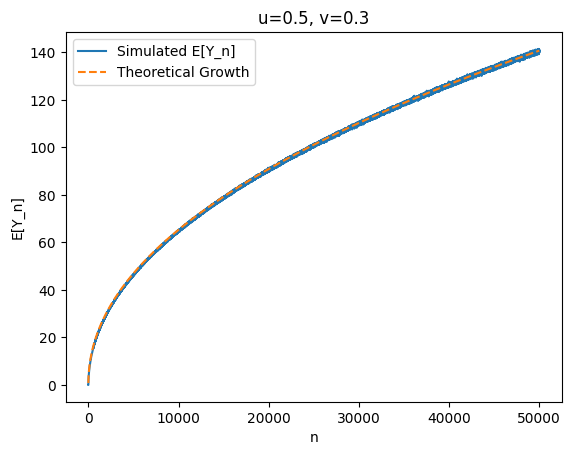

In [6]:
N = 50000
n_particales = 100000
u=0.5
v=0.3

print(f"u={u}, v={v}")
Yns = simulate_Yn(N, n_particales, u, v)
EYns = np.mean(Yns, axis=1)

alpha_star = 0.4769007682800294

normalizing_constant = EYns[-1]/(N ** alpha_star)
print("Normalizing constant:", normalizing_constant)

plt.plot(EYns, label='Simulated E[Y_n]')
plt.plot(np.arange(1, N+1), np.arange(1, N+1)**alpha_star * normalizing_constant, label='Theoretical Growth', linestyle='dashed')
plt.xlabel('n')
plt.ylabel('E[Y_n]')
plt.legend()
plt.title(f'u={u}, v={v}')
plt.show()

Normalizing constant: 0.8074843311729373


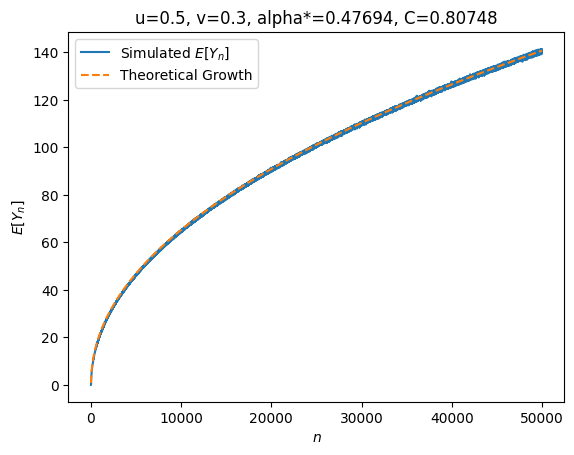

In [9]:
alpha_star = 0.47694240328599447

normalizing_constant = EYns[-1]/(N ** alpha_star)
print("Normalizing constant:", normalizing_constant)

plt.plot(EYns, label='Simulated $E[Y_n]$')
plt.plot(np.arange(1, N+1), np.arange(1, N+1)**alpha_star * normalizing_constant, label='Theoretical Growth', linestyle='dashed')
plt.xlabel('$n$')
plt.ylabel('$E[Y_n]$')
plt.legend()
plt.title(f'u={u}, v={v}, alpha*={alpha_star:.5f}, C={normalizing_constant:.5f}')
plt.show()

#### Simpler case where there is only the sum

In [ ]:
def simulate_Yn(max_N, num_particles):

    history = np.zeros((max_N + 1, num_particles), dtype=int)
    
    for n_target in range(2, max_N + 1):
        n = n_target - 1

        # Uniform indices
        Un = np.random.randint(0, n, size=num_particles)
        idx1 = Un
        idx2 = n - 1 - Un
        
        # Sample independent copies Y^(1) and Y^(2) 
        p_idx1 = np.random.randint(0, num_particles, size=num_particles)
        p_idx2 = np.random.randint(0, num_particles, size=num_particles)
        
        y1 = history[idx1, p_idx1]
        y2 = history[idx2, p_idx2]
      
        # Apply the recurrence formula conditionally
        y_new = np.zeros(num_particles, dtype=int)
        y_new = y1 + y2 + 1
        
        history[n_target] = y_new
        
    # Calculate the empirical expectation E[Y_n] across the particles
    expectations = np.mean(history, axis=1)
    
    return expectations, history

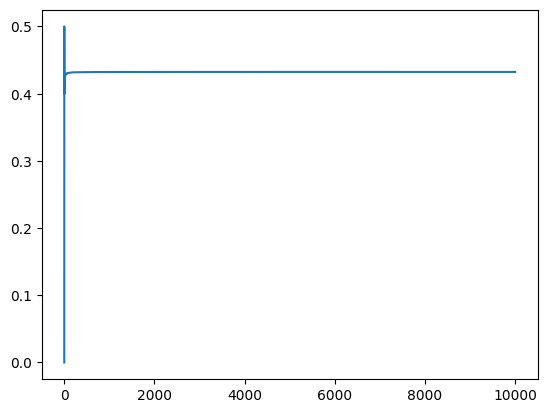

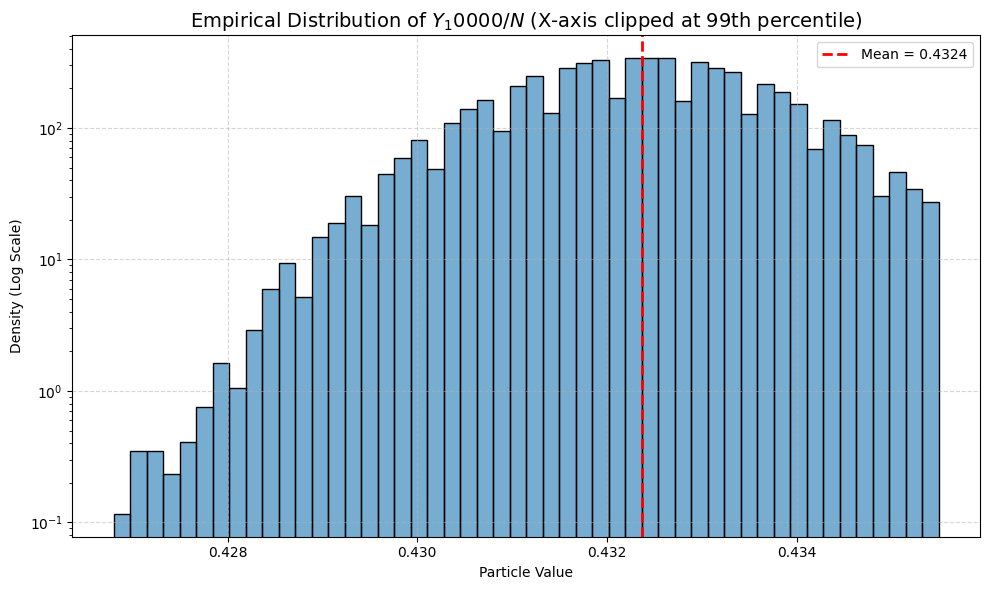

In [ ]:
N = 10000

expectations, history = simulate_Yn(N, 100000)

n = np.arange(1, N+1)
plt.plot(n, expectations[1:]/n, label=f'Empirical $E[Y_n]/n$')
plt.xlabel('n')
plt.ylabel('E[Y_n]/n')
plt.legend()
plt.title('Empirical E[Y_n]/n')
plt.show()

Xns = np.zeros_like(history, dtype=float)
Xns[1:] = history[1:] / n[:, None]

plot_distribution(Xns[-1], title=f"Empirical Distribution of $Y_{N}/N$", bins=50, clip_percentile=99, 
                  log_y=True, show_bins=True, show_kde=False)

In [35]:
np.mean(Xns[-1])

np.float64(0.432367108)

(200.0, 300.0)

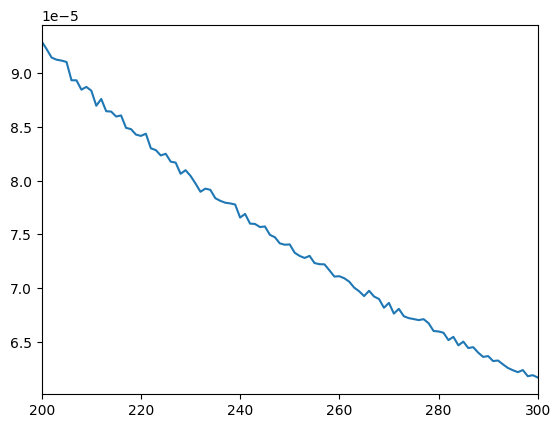

In [ ]:
start_idx = 200
end_idx = 300
x = np.arange(start_idx, end_idx+1)
y = np.var(Xns[start_idx:end_idx+1], axis=1)
plt.plot(x, y, label=f'Empirical Var($Y_n/n$)')
plt.xlabel('n')
plt.ylabel('Var(Y_n/n)')
plt.legend()
plt.xlim(start_idx, end_idx)

In [21]:
str(SR('u**2+v^2'))

'u^2 + v^2'

In [44]:
np.var(Xns[5:])

np.float64(1.5022196522303259e-05)